### Install required libraries

Using torchaudio==2.8 here as 2.9 forces the use of torchcodec:

In [45]:
%pip install --upgrade pip
%pip install pandas numpy matplotlib torch torchaudio==2.8 soundfile --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Imports

In [46]:
from IPython.display import Audio

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch, torchaudio
import torch.nn as nn

from torch import Tensor
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from utils import get_transformation_pipeline, FixAudioLength, AudioDataset

### Constants

In [47]:
INPUT_DIR = 'data'
MODEL_PATH = 'models/best_cnn.pth'

# Audio data
ORIGINAL_SAMPLE_RATE = 48_000
TARGET_SAMPLE_RATE = 16_000
TARGET_AUDIO_LENGTH = 0.84
TARGET_SAMPLES = int(TARGET_SAMPLE_RATE * TARGET_AUDIO_LENGTH)

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 10

NUM_MELS = 64

### Setting up device to use

In [48]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Visualising audio data

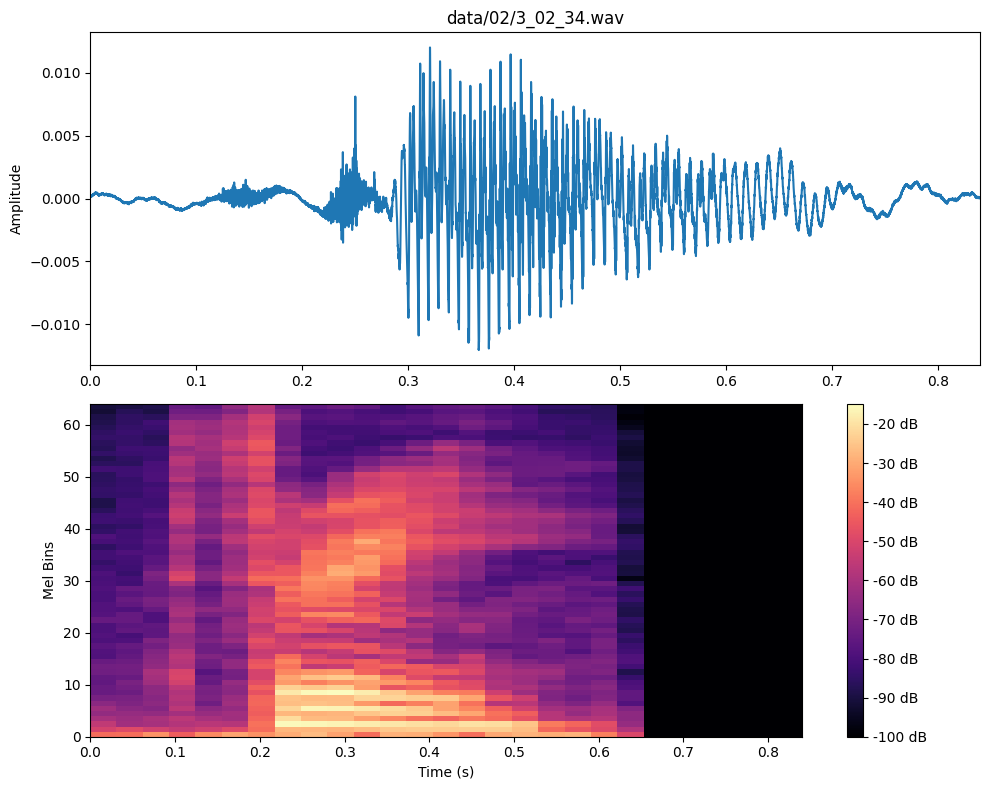

Old samples: 30145
Old duration: 0.63s
New samples: 13440
New duration: 0.84s


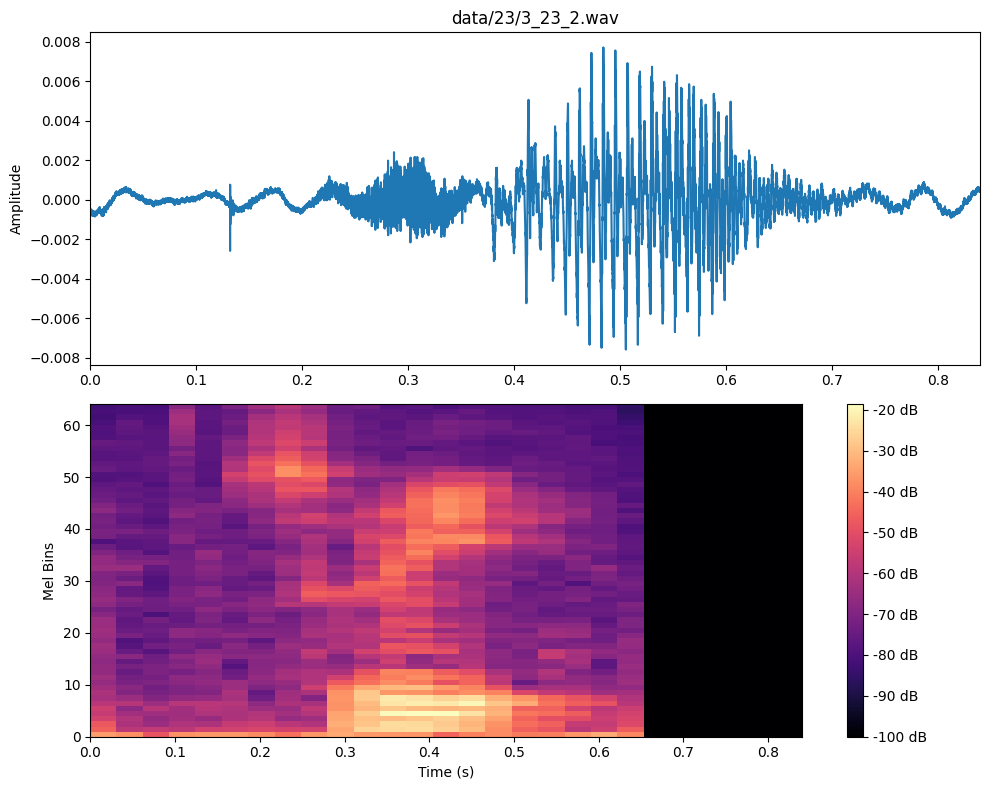

Old samples: 30574
Old duration: 0.64s
New samples: 13440
New duration: 0.84s


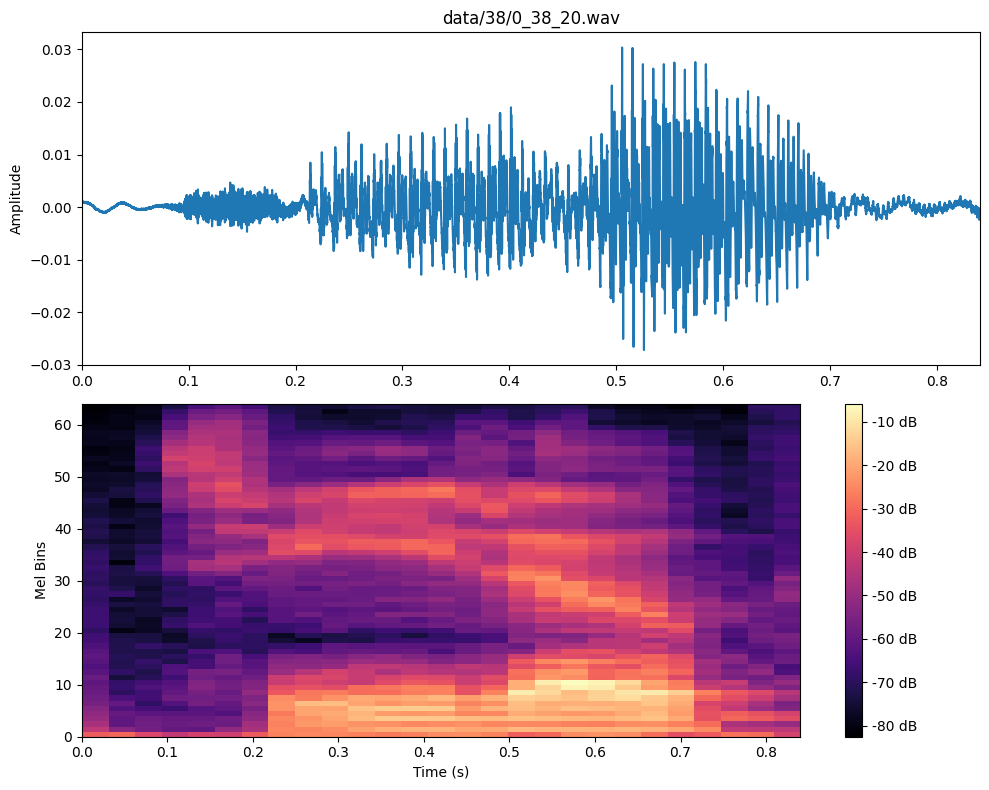

Old samples: 41622
Old duration: 0.87s
New samples: 13440
New duration: 0.84s


In [49]:
def visualise_audio_data() -> None:
    resampler = torchaudio.transforms.Resample(
        orig_freq=ORIGINAL_SAMPLE_RATE,
        new_freq=TARGET_SAMPLE_RATE
    )
    pipeline = get_transformation_pipeline()

    for i in range(3):
        # Randomly select a digit, speaker and sample
        digit = np.random.randint(0, 10)
        speaker = np.random.randint(1, 61)
        sample = np.random.randint(0, 50)

        if speaker < 10:
            file = f'{INPUT_DIR}/0{speaker}/{digit}_0{speaker}_{sample}.wav'
        else:
            file = f'{INPUT_DIR}/{speaker}/{digit}_{speaker}_{sample}.wav'

        # Do the resampling + audio length fixing here so we have access to the modified waveform
        waveform, sample_rate = torchaudio.load(file, normalize=True)
        old_samples = waveform.shape[1]
        old_duration = waveform.shape[1] / sample_rate

        new_waveform = FixAudioLength()(resampler(waveform))
        new_sample_rate = TARGET_SAMPLE_RATE
        new_samples = new_waveform.shape[1]
        new_duration = new_waveform.shape[1] / new_sample_rate

        mel_spectrogram = pipeline(waveform)

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

        # Waveform
        ax1.plot(np.linspace(0, new_duration, waveform.shape[1]), waveform.t().numpy())
        ax1.set_xlim(0, new_duration)
        ax1.set_title(file)
        ax1.set_ylabel('Amplitude')

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, NUM_MELS],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')
        fig.colorbar(img, ax=ax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        display(Audio(data=waveform, rate=sample_rate))
        print(f'Old samples: {old_samples}')
        print(f'Old duration: {old_duration:.2f}s')
        print(f'New samples: {new_samples}')
        print(f'New duration: {new_duration:.2f}s')

visualise_audio_data()

### Determining the 95th percentile for audio lengths

In [50]:
# Need this to be able to determine the best time to truncate / pad to
def calculate_audio_lengths() -> None:
    audio_files = glob.glob(os.path.join(INPUT_DIR, '**/*.wav'), recursive=True)

    durations = []
    for file in tqdm(audio_files):
        info = torchaudio.info(file)
        duration = info.num_frames / info.sample_rate
        durations.append(duration)

    durations = np.array(durations)

    plt.hist(durations, bins=60)
    plt.title('Distribution of audio durations')
    plt.xlabel('Seconds')
    plt.ylabel('No. of files')
    plt.show()

    print(f'95% percentile: {np.percentile(durations, 95):.2f}s')

### Audio classifier using a CNN

In [51]:
# TODO: Test with leaky RELU
class AudioClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        conv_layers = []

        # First convolutional block
        self.conv1 = nn.Conv2d(1, 8, kernel_size=5, stride=2, padding=2)
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(8)
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        conv_layers += [self.conv1, self.relu1, self.bn1]

        # Second convolution block
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1)
        self.relu2 = nn.ReLU()
        self.bn2 = nn.BatchNorm2d(16)
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')
        conv_layers += [self.conv2, self.relu2, self.bn2]

        # Third convolution block
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.relu3 = nn.ReLU()
        self.bn3 = nn.BatchNorm2d(32)
        nn.init.kaiming_normal_(self.conv3.weight, nonlinearity='relu')
        conv_layers += [self.conv3, self.relu3, self.bn3]

        # Wrap convolution blocks together
        self.conv_layers = nn.Sequential(*conv_layers)

        # Global pooling
        self.global_avg_pooling = nn.AdaptiveAvgPool2d(1)

        # Linear classifier
        self.classifier = nn.Linear(32, 10)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

### Training, validation and testing code

In [55]:
def train(model, train_dataloader, optimizer, criterion) -> float:
    model.train()

    total_loss = 0.0
    for data in tqdm(train_dataloader, desc='Training', unit='batches'):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_dataloader)

def validate(model, val_dataloader, criterion) -> tuple[float, float]:
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in tqdm(val_dataloader, desc='Validation', unit='batches'):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_dataloader)
    avg_accuracy = 100 * correct / total

    return avg_loss, avg_accuracy

def test(model, test_dataloader) -> float:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model = model.to(device)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data in tqdm(test_dataloader, desc='Testing', unit='batches'):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

### Training script

In [56]:
if __name__ == '__main__':
    # Define our dataset and dataloaders
    dataset = AudioDataset(data_dir=INPUT_DIR, pipeline=get_transformation_pipeline())

    # Split dataset into training, validation and test sets
    # Using an 80/10/10 split
    train_size = int(0.8 * len(dataset))
    val_size = int(0.1 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
    )

    train_dataloader = DataLoader(train_dataset, batch_size=32, num_workers=4, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=32, num_workers=4)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Train the model
    model = AudioClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # Keep track of best model
    best_accuracy = 0.0
    for epoch in range(NUM_EPOCHS):
        saved = False

        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss = train(model, train_dataloader, optimizer, criterion)
        val_loss, accuracy = validate(model, val_dataloader, criterion)

        if (accuracy > best_accuracy):
            saved = True
            best_accuracy = accuracy
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Training Loss: {train_loss:.2f} | Validation Loss: {val_loss:.2f} | Accuracy: {accuracy:.2f}%')
        print()
    print(f'Best model had an accuracy of {best_accuracy:.2f}%.')
    print(f'Running final test:')
    test_accuracy = test(model, test_dataloader)
    print(f'Final test accuracy: {test_accuracy:.2f}%')

Features shape: torch.Size([32, 1, 64, 27])
Labels shape: torch.Size([32])

[Epoch 1/10]


Validation: 100%|██████████| 94/94 [00:04<00:00, 23.06batches/s]


Training Loss: 1.13 | Validation Loss: 0.52 | Accuracy: 87.77% [SAVED]

[Epoch 2/10]


Validation: 100%|██████████| 94/94 [00:03<00:00, 23.85batches/s]


Training Loss: 0.36 | Validation Loss: 0.24 | Accuracy: 94.30% [SAVED]

[Epoch 3/10]


...

Training Loss: 0.05 | Validation Loss: 0.05 | Accuracy: 98.70% [SAVED]

[Epoch 10/10]


Validation: 100%|██████████| 94/94 [00:04<00:00, 22.32batches/s]


Training Loss: 0.04 | Validation Loss: 0.04 | Accuracy: 98.80% [SAVED]

Best model had an accuracy of 98.80%.
Running final test:


Testing: 100%|██████████| 94/94 [00:04<00:00, 22.45batches/s]

Final test accuracy: 98.90%
